Shape: (11500, 180)
Columns: Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       ...
       'X170', 'X171', 'X172', 'X173', 'X174', 'X175', 'X176', 'X177', 'X178',
       'y'],
      dtype='object', length=180)


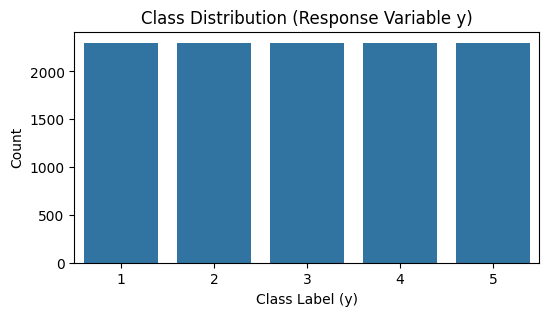

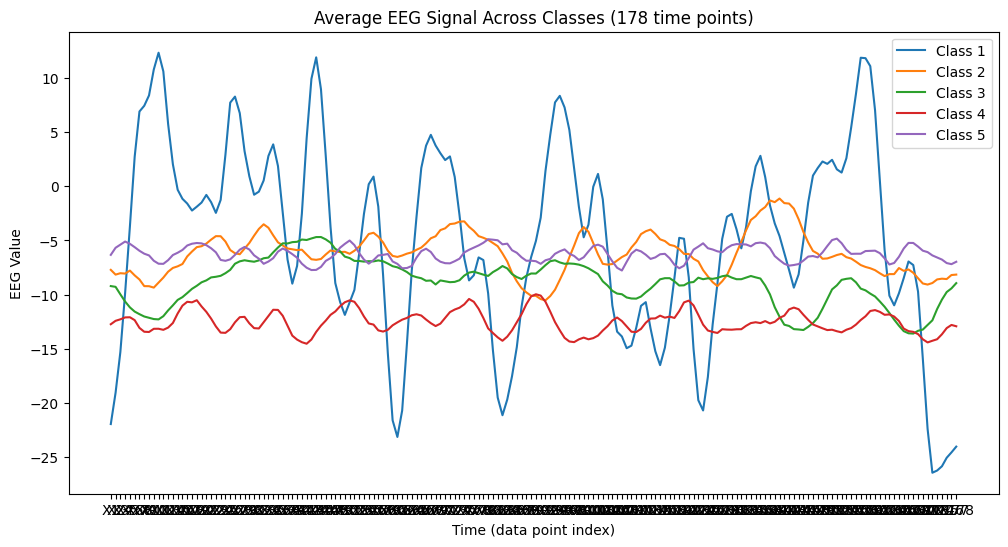

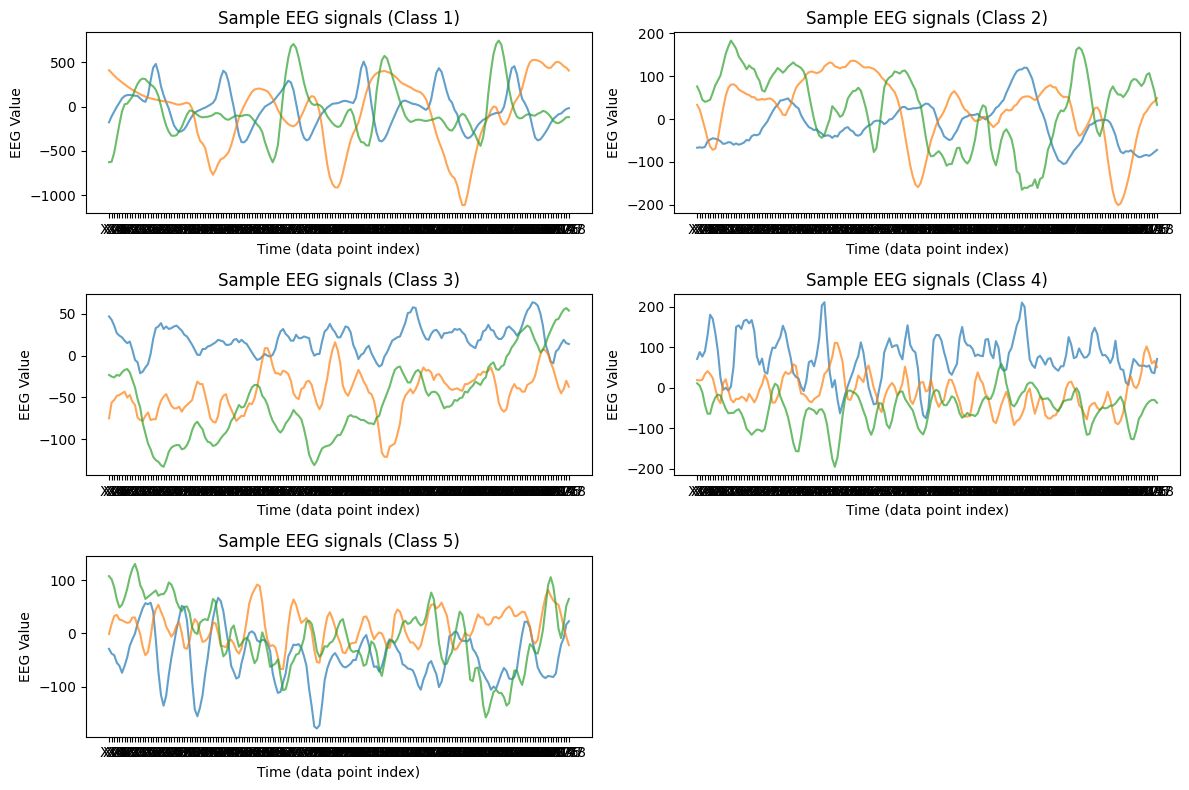

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV data
df = pd.read_csv('data.csv')  # Change to your actual filename

# Display basic dataset info
print("Shape:", df.shape)
print("Columns:", df.columns)

# Columns: X1-X178 are EEG data points, y is the label
X_cols = [f"X{i}" for i in range(1, 179)]
y_col = 'y'

# Visualize class distribution
plt.figure(figsize=(6,3))
sns.countplot(x=y_col, data=df)
plt.title("Class Distribution (Response Variable y)")
plt.xlabel("Class Label (y)")
plt.ylabel("Count")
plt.show()

# Plot mean signal for each class over the 178 time points
plt.figure(figsize=(12, 6))
for y_class in sorted(df[y_col].unique()):
    mean_signal = df[df[y_col] == y_class][X_cols].mean()
    plt.plot(mean_signal, label=f"Class {y_class}")
plt.title("Average EEG Signal Across Classes (178 time points)")
plt.xlabel("Time (data point index)")
plt.ylabel("EEG Value")
plt.legend()
plt.show()

# Visualize random sample EEG signals from each class
plt.figure(figsize=(12, 8))
samples_per_class = 3
for i, y_class in enumerate(sorted(df[y_col].unique()), 1):
    plt.subplot(3, 2, i)
    samples = df[df[y_col] == y_class].sample(samples_per_class)
    for _, row in samples.iterrows():
        plt.plot(row[X_cols], alpha=0.7)
    plt.title(f"Sample EEG signals (Class {y_class})")
    plt.xlabel("Time (data point index)")
    plt.ylabel("EEG Value")
plt.tight_layout()
plt.show()

